In [41]:
from matplotlib.ticker import LogLocator, FuncFormatter
import numpy as np
import glob
import sinter 
import re
import matplotlib.pyplot as plt
import pickle
import random
import matplotlib.colors as mcolors
import re

def round_sig_fig(x, sig):
    if x == 0.0:
        result = 0
    else:
        result = round(x, sig - int(np.floor(np.log10(abs(x)))) - 1)
    return result

stats_list = glob.glob('../collected_stats/helios_noise/without_leakage/*exclude_vs_include*.csv')

stats = sinter.stats_from_csv_files(*stats_list)

# # # How to save collected stats as pickle
# with open('../collected_stats/helios_noise/other_investigations/gross_w_leakage.csv', 'wb') as f:
    # pickle.dump(stats, f)

## How to import collected stats:
# with open('../collected_stats/helios_noise/all_helios.pkl', 'rb') as f:
#     stats = pickle.load(f)

In [2]:
plt.style.use("dark_background")

In [80]:
# Delete some circuits you don't want to plot
stats.sort(key=lambda s: (s.json_metadata["n"], s.json_metadata["p"]))
stats = [s for s in stats if s.json_metadata['n'] != 60]

# Print
print(f"   code         p      correl.       shots  errors  seconds  sec/shot   pL")
for stat in stats:
    # print(stat)
    print(f"[[{stat.json_metadata['n']:3},{stat.json_metadata['k']:2},{stat.json_metadata['d']:2}]]  {stat.json_metadata['p']:2}   {'True' if stat.json_metadata['excl_opp_detectors'] == 'False' else 'False':5}     {stat.shots:9}    {stat.errors:3}  {round(stat.seconds):8}   {round_sig_fig(stat.seconds/stat.shots,2):6}   {round_sig_fig(stat.errors/stat.shots/20, 2)}")

   code         p      correl.       shots  errors  seconds  sec/shot   pL
[[ 72,12, 6]]  0.001   True         201606     20     72609     0.36   5e-06
[[ 72,12, 6]]  0.001   False        439266    102       896    0.002   1.2e-05
[[ 72,12, 6]]  0.002   True          19039     24     18906     0.99   6.3e-05
[[ 72,12, 6]]  0.002   False         64754    127       516    0.008   9.8e-05
[[ 72,12, 6]]  0.003   True           9835     55     18813      1.9   0.00028
[[ 72,12, 6]]  0.003   False         10770    109       250    0.023   0.00051
[[144,12,12]]  0.001   True        2017845      0  10609956      5.3   0
[[144,12,12]]  0.001   False      31784472     20    140067   0.0044   3.1e-08
[[144,12,12]]  0.002   True         136832      4   2190510     16.0   1.5e-06
[[144,12,12]]  0.002   False        821611     28     25345    0.031   1.7e-06
[[144,12,12]]  0.003   True          73548     19   2043218     28.0   1.3e-05
[[144,12,12]]  0.003   False        155462     59     21082     

In [4]:
def my_axis_options(ax, stats, title = ''):
    # ax.loglog()
    ax.plot()
    ax.set_yscale('log')
    
    ax.set_ylabel(r"$p_L$ per round")
    ax.grid()
    ax.grid(False, axis = 'x', which = 'minor')
    ax.set_ylim(1e-8, 1e-3)
    handles, labels = ax.get_legend_handles_labels()
    leg = ax.legend(handles, labels,
                    framealpha=0.4, 
                    # loc = 'upper left', 
                    reverse = True, ncol = 1,
                    # fontsize = 14,
                    )

    ## When x-axis is Helios noise:
    ax.set_xlabel(r"$p\ \times\ $ Helios Table ") ## Helios noise
    ax.xaxis.set_major_locator(LogLocator(10, subs=(1,2,3,4,5,6)))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v,_: ({1:"1",2:"2",3:"3",4:"4",5:"5",6:"6"}.get(int(round(v/10**np.floor(np.log10(v)))), "")) if v>0 else ""))
    ax.minorticks_off()

    # ## When x-axis is [[n, k, d]]
    # codes = sorted({(s.json_metadata['n'], s.json_metadata['k'], s.json_metadata['d']) for s in stats})
    # ax.set_xticks(range(len(codes)))
    # ax.set_xticklabels([f"[[{n},{k},{d}]]" for n, k, d in codes])
    
    
    ax.set_title(f"{title}")
    ax.figure.savefig(f"../scrap.pdf", dpi = 300, bbox_inches = "tight")


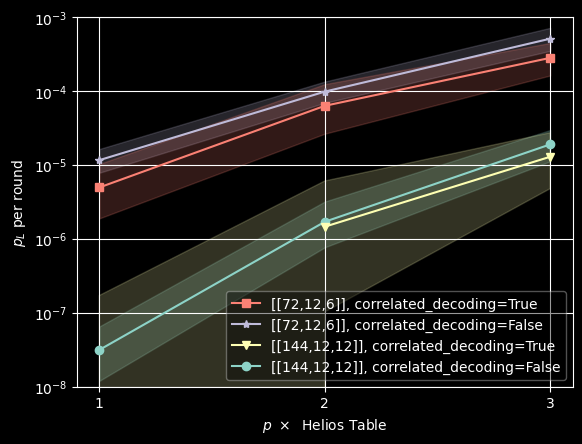

In [5]:
fig, ax = plt.subplots()#figsize=(10, 6))
code_to_x = {code: i for i, code in enumerate(sorted({(s.json_metadata['n'], s.json_metadata['k'], s.json_metadata['d']) for s in stats}))}
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s:    # code_to_x[(s.json_metadata['n'], s.json_metadata['k'], s.json_metadata['d'])],
                        # stats.json_metadata['n'],
                        1000 *s.json_metadata['p'], #multiply by 1e3 if want as multiple of Helios noise
    
    group_func=lambda s: f"[[{s.json_metadata['n']},{s.json_metadata['k']},{s.json_metadata['d']}]], correlated_decoding={'True' if s.json_metadata['excl_opp_detectors']=='False' else 'False'}", 
    failure_units_per_shot_func = lambda s: s.json_metadata['r'], # s.json_metadata['k'],

    filter_func=lambda s: (
    s.json_metadata['n'] != 60 and
    s.json_metadata['l'] != 30
    and s.json_metadata['l'] != 21
    and (
        s.json_metadata['n'] != 288
        or s.json_metadata['k'] != 16
    )),
    # plot_args_func = lambda index, curve_id: {'color': 'blue' if '18_' in curve_id else 'cyan' if '48' in curve_id else 'green' if '108' in curve_id else 'red' if '144' in curve_id else 'orange' if '90' in curve_id else 'blue' if '72' in curve_id else 'black' if '288' in curve_id else 'magenta' if '360' in curve_id else 'olive' if '192' in curve_id else 'cyan' if '216' in curve_id else 'brown' if '128' in curve_id else 'gray' if '64' in curve_id else 'rebeccapurple' if '378' in curve_id else random.choice(list(mcolors.TABLEAU_COLORS.values())), 'marker': 'o'}
        )
# my_axis_options(ax, stats, title=r'BB codes on our Helios-inspired design w/ leakage repumping and $p_\text{loss}=10^{-7}$')
my_axis_options(ax, stats, title=r'')